In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('..\data\placementdata.csv')

In [3]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [4]:
df.isnull().sum()

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [5]:
def add_iq_score_correlated(df):
    np.random.seed(42)
    
    base_iq = np.random.normal(100, 15, len(df))
    
    cgpa_effect = (df['CGPA'] - df['CGPA'].mean()) / df['CGPA'].std() * 5
    aptitude_effect = (df['AptitudeTestScore'] - df['AptitudeTestScore'].mean()) / df['AptitudeTestScore'].std() * 3
    
    iq_scores = base_iq + cgpa_effect + aptitude_effect
    
    iq_scores += np.random.normal(0, 3, len(df))
    
    iq_scores = np.clip(iq_scores, 60, 160)
    iq_scores = np.round(iq_scores).astype(int)
    
    df.insert(1, 'IQ_Score', iq_scores)
    
    correlation_cgpa = df['IQ_Score'].corr(df['CGPA'])
    correlation_aptitude = df['IQ_Score'].corr(df['AptitudeTestScore'])
    
    print(f" Added correlated IQ scores")
    print(f"   Correlation with CGPA: {correlation_cgpa:.3f}")
    print(f"   Correlation with Aptitude: {correlation_aptitude:.3f}")

In [6]:
add_iq_score_correlated(df)

 Added correlated IQ scores
   Correlation with CGPA: 0.388
   Correlation with Aptitude: 0.311


In [7]:
df.head()

,StudentID,IQ_Score,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,99,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,110,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,106,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,124,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,107,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [8]:
df['PlacementStatus'] = df['PlacementStatus'].map({'Placed': 1, 'NotPlaced': 0})
df['ExtracurricularActivities'] = df['ExtracurricularActivities'].map({'Yes': 1, 'No': 0})
df['PlacementTraining'] = df['PlacementTraining'].map({'Yes': 1, 'No': 0})
df.head()

,StudentID,IQ_Score,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,99,7.5,1,1,1,65,4.4,0,0,61,79,0
1,2,110,8.9,0,3,2,90,4.0,1,1,78,82,1
2,3,106,7.3,1,2,2,82,4.8,1,0,79,80,0
3,4,124,7.5,1,1,2,85,4.4,1,1,81,80,1
4,5,107,8.3,1,2,2,86,4.5,1,1,74,88,1


In [9]:
df.describe()

,StudentID,IQ_Score,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,100.054000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,0.585400,0.731800,69.159400,74.501500,0.419700
std,2886.89568,16.714455,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,0.492677,0.443044,10.430459,8.919527,0.493534
min,1.00000,60.000000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,0.000000,0.000000,55.000000,57.000000,0.000000
25%,2500.75000,89.000000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,0.000000,0.000000,59.000000,67.000000,0.000000
50%,5000.50000,100.000000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,1.000000,1.000000,70.000000,73.000000,0.000000
75%,7500.25000,111.000000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,1.000000,1.000000,78.000000,83.000000,1.000000
max,10000.00000,160.000000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,1.000000,1.000000,90.000000,88.000000,1.000000


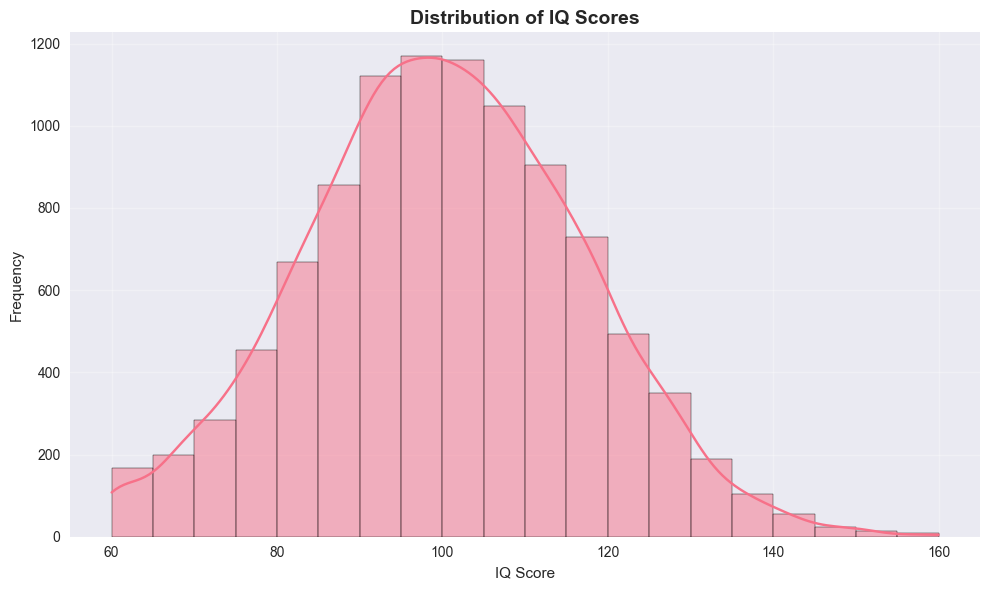

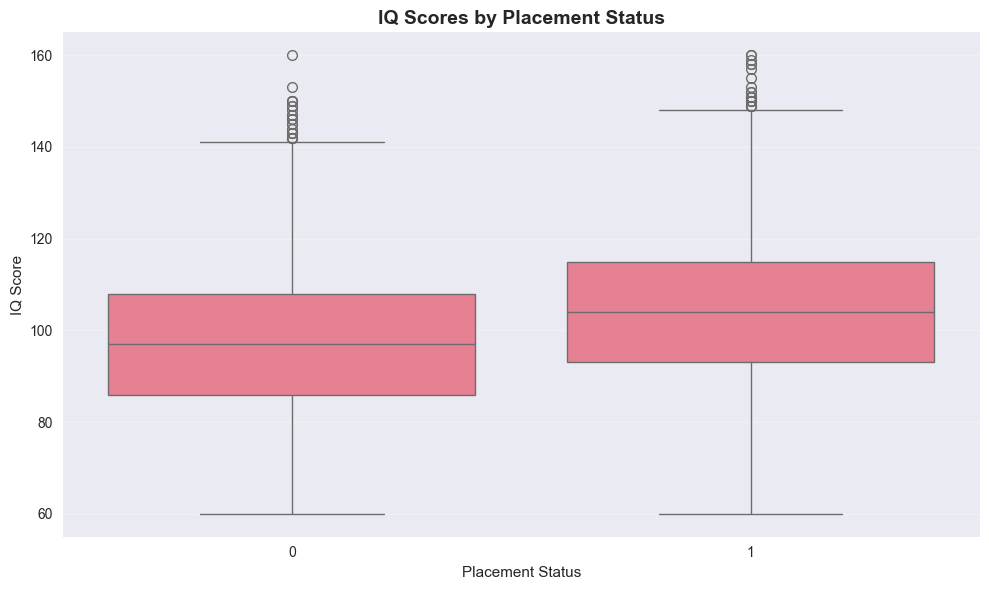

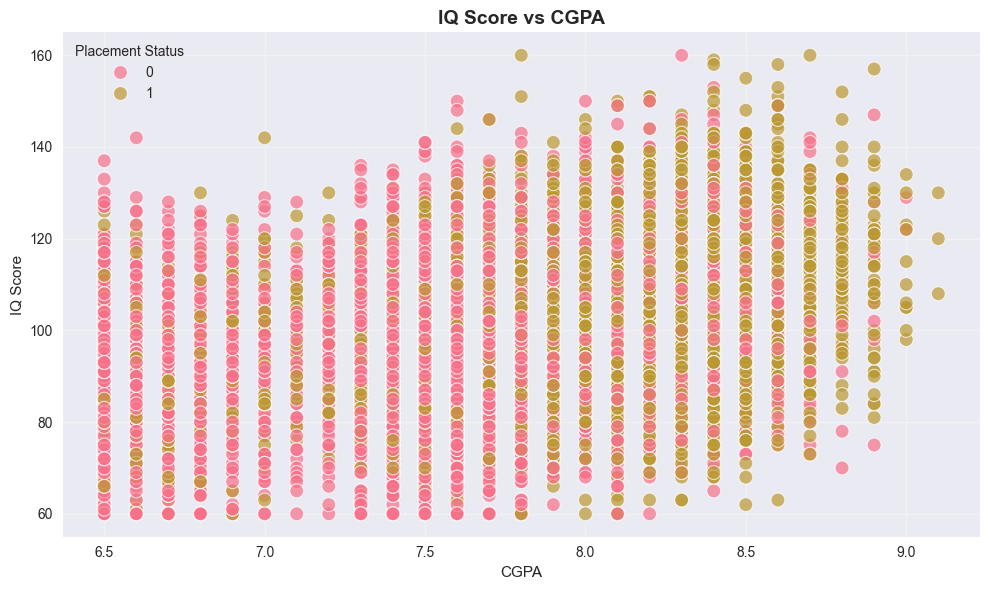

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn')
sns.set_palette("husl")

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='IQ_Score', kde=True, bins=20)
plt.title('Distribution of IQ Scores', fontsize=14, fontweight='bold')
plt.xlabel('IQ Score')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('iq_distribution.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='PlacementStatus', y='IQ_Score')
plt.title('IQ Scores by Placement Status', fontsize=14, fontweight='bold')
plt.xlabel('Placement Status')
plt.ylabel('IQ Score')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('iq_vs_placement.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='CGPA', y='IQ_Score', hue='PlacementStatus', s=100, alpha=0.7)
plt.title('IQ Score vs CGPA', fontsize=14, fontweight='bold')
plt.xlabel('CGPA')
plt.ylabel('IQ Score')
plt.grid(True, alpha=0.3)
plt.legend(title='Placement Status')
plt.tight_layout()
plt.savefig('iq_vs_cgpa.png', dpi=150)
plt.show()

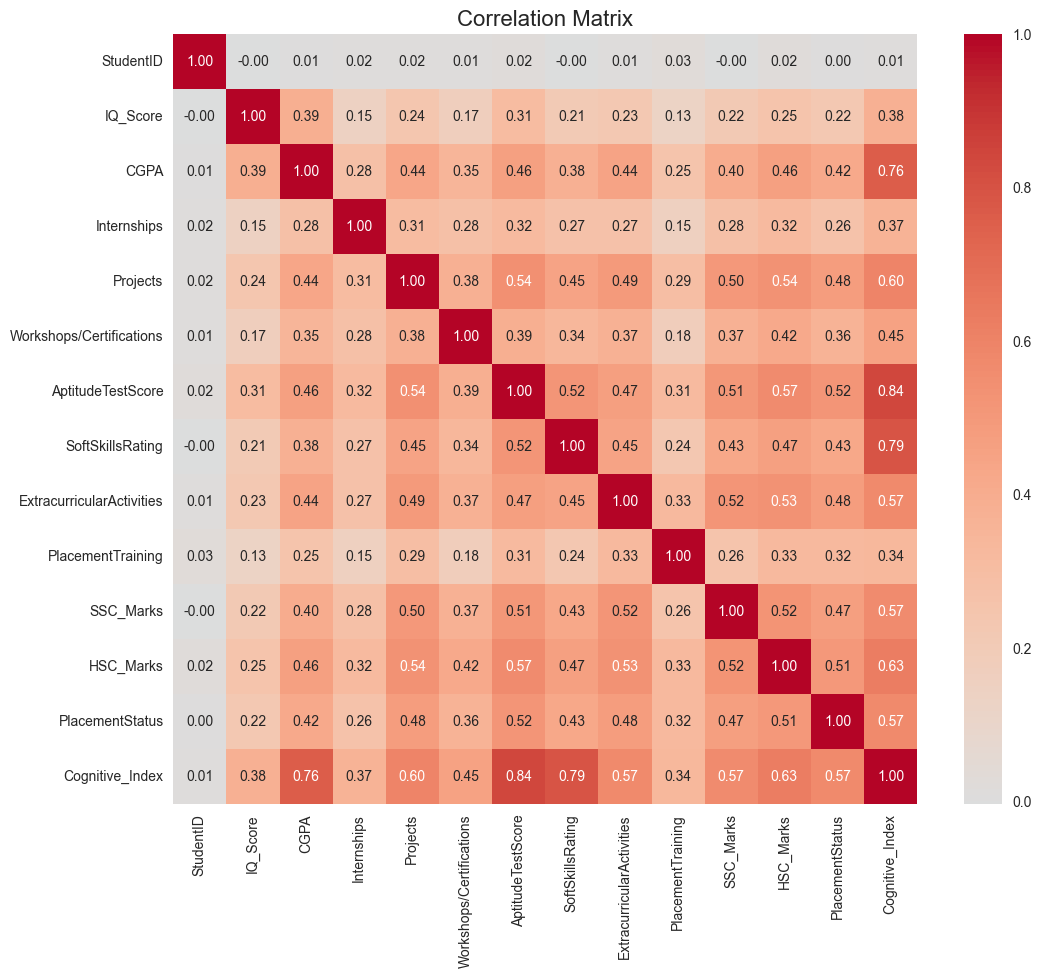

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix', fontsize=16)
plt.show()